In [1]:
import numpy as np
import pandas as pd

from molfeat.trans import MoleculeTransformer

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator, Draw
from rdkit.Chem.inchi import MolToInchi

from CSDTools.processing import (
    DISCRETE_PARAMS, CELL_PARAMS,
    find_duplicate_clusters, forms_for_smiles,
    build_polymorph_table,
)

In [2]:
data = pd.read_csv("csd_cleaned.csv")
data

,identifier,chemical_name,is_racemic_name,is_organic,has_metal,num_components,is_single_species,has_disorder,disorder_details,color,...,cell_angle_beta,cell_angle_gamma,cell_volume,reduced_cell_a,reduced_cell_b,reduced_cell_c,reduced_cell_alpha,reduced_cell_beta,reduced_cell_gamma,num_forms
0,AABHTZ,"4-Acetoamido-3-(1-acetyl-2-(2,6-dichlorobenzyl...",False,True,False,1,True,False,NaN,NaN,...,71.070,96.160,769.978363,7.3590,10.2720,11.365707,84.217121,71.162715,71.250,1
1,AACFAZ10,"N,N'-bis(3-Acetyl-4-(2-chlorophenyl)-4-hydroxy...",False,True,False,1,True,False,NaN,red,...,90.000,90.000,2475.361224,6.1620,19.9540,20.132000,90.000000,90.000000,90.000,1
2,AACMHX10,"α-Acetoxy-α,2-anti-diphenylmethylene-cyclohexane",False,True,False,1,True,False,NaN,NaN,...,90.000,90.000,3455.164356,8.5350,16.7580,24.157000,90.000000,90.000000,90.000,1
3,AADRIB,"1,2,3,4-Tetra-O-acetyl-α-D-ribopyranose",False,True,False,2,True,False,NaN,NaN,...,109.180,90.000,1591.259021,8.5900,11.4530,16.443713,90.000000,100.383702,90.000,1
4,AAMTXP,"(a,a)-bis(4,6-Dimethyl-2-thioxo-1,3,2-dioxapho...",False,True,False,1,True,False,NaN,NaN,...,113.380,90.000,1673.976496,9.8870,12.3250,14.966000,113.380000,90.000000,90.000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332380,ZUVJOS01,"tris(2,4,6-tribromophenyl)methyl radical",False,True,False,1,True,False,NaN,red,...,100.904,90.000,2359.166565,8.4619,14.4325,19.672600,90.000000,100.904000,90.000,3
332381,ZUYBOM01,"2-(4-chlorophenyl)-1,3-benzothiazole",False,True,False,1,True,False,NaN,colorless,...,98.556,90.000,1101.366516,7.1466,11.0497,14.104000,90.000000,90.000000,98.556,2
332382,ZZZEIG05,triphenylarsane,False,True,False,4,True,False,NaN,whiteish colorless,...,80.072,86.361,2999.830947,11.2004,15.2918,17.882400,84.551000,80.072000,86.361,5
332383,ZZZOLM02,docosanoic acid,False,True,False,1,True,False,NaN,colorless,...,90.052,90.000,2089.560807,5.5210,7.1540,52.904000,90.000000,90.052000,90.000,2


In [29]:
smiles_list, label_list = data["smiles"].to_list(), data["num_forms"].to_list(

# convert to binary classification
label_list = np.where(np.array(label_list) > 1, 1, 0)

In [30]:
desc_calc = MoleculeTransformer(featurizer='fcfp', dtype=float)
x = desc_calc(smiles_list)

[15:58:09] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[15:58:09] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[15:58:11] WARNING: not removing hydrogen atom without neighbors
[15:58:11] WARNING: not removing hydrogen atom without neighbors
[15:58:11] WARNING: not removing hydrogen atom without neighbors
[15:58:11] WARNING: not removing hydrogen atom without neighbors
[15:58:11] WARNING: not removing hydrogen atom without neighbors
[15:58:11] WARNING: not removing hydrogen atom without neighbors
[15:58:11] WARNING: not removing hydrogen atom without neighbors
[15:58:11] WARNING: not removing hydrogen atom without neighbors
[15:58:11] WARNING: not removing hydrogen atom without neighbors
[15:58:11] WARNING: not removing hydrogen atom without neighbors
[15:58:11] WARNING: not removing hydrogen atom without neighbors
[15:58:11] WARNING: not removing hydrogen atom without neig

### 2. Molecular similarity (Tanimoto)

In [32]:
# Example molecules
smiles1 = "CCO"
smiles2 = "CCCO"

mol1 = Chem.MolFromSmiles(smiles1)
mol2 = Chem.MolFromSmiles(smiles2)

# Create Morgan fingerprint generator
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# Generate fingerprints
fp1 = morgan_gen.GetFingerprint(mol1)
fp2 = morgan_gen.GetFingerprint(mol2)

# Compute Tanimoto similarity
similarity = DataStructs.TanimotoSimilarity(fp1, fp2)

print(similarity)

0.5555555555555556


#### Similarity enriched table

For each of the ~3M (molecule, neighbor) pairs from `similarity_top10.csv`, join the number of crystal forms and the full list of CSD identifiers for both SMILES. Saved to `similarity_enriched.csv` for downstream analysis (see `4bis_Similarity_Analysis.ipynb`).

In [3]:
sim_top10 = pd.read_csv("similarity_top10.csv")

# Deduplicated form count: build_polymorph_table clusters re-measured/re-deposited
# identical structures (same reduced cell, same spacegroup) instead of counting
# raw CSD entries, so a molecule studied 3x in the same form is monomorphic,
# not "3 polymorphs".
poly_table = build_polymorph_table(data)
inchi_to_forms = poly_table.set_index("inchi_single")["num_distinct_forms"]
data["num_distinct_forms"] = data["inchi_single"].map(inchi_to_forms)

smiles_agg = (
    data.groupby("smiles")
    .agg(
        nb_forms=("num_distinct_forms", "max"),
        identifiers=("identifier", lambda x: "|".join(sorted(x))),
    )
    .reset_index()
)

similarity_enriched = (
    sim_top10
    .merge(
        smiles_agg.rename(columns={"smiles": "smiles", "nb_forms": "nb_forms_1", "identifiers": "identifiers_1"}),
        on="smiles", how="left",
    )
    .merge(
        smiles_agg.rename(columns={"smiles": "neighbor_smiles", "nb_forms": "nb_forms_2", "identifiers": "identifiers_2"}),
        on="neighbor_smiles", how="left",
    )
    .rename(columns={"smiles": "smiles_1", "neighbor_smiles": "smiles_2"})
    [["smiles_1", "nb_forms_1", "identifiers_1", "smiles_2", "nb_forms_2", "identifiers_2", "tanimoto"]]
)

similarity_enriched.to_csv("similarity_enriched.csv", index=False)
print(f"{len(similarity_enriched):,} pairs saved → similarity_enriched.csv")
similarity_enriched

3,040,320 pairs saved → similarity_enriched.csv


,smiles_1,nb_forms_1,identifiers_1,smiles_2,nb_forms_2,identifiers_2,tanimoto
0,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1.0,AABHTZ,Nn1cnnc1NN=Cc1c(Cl)cccc1Cl,1.0,CIJGAD,0.379310
1,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1.0,AABHTZ,CN(N=Cc1c(Cl)cccc1Cl)C(=O)C1COC(=O)N1C,1.0,HUMJOQ,0.348485
2,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1.0,AABHTZ,CC(=O)NC1=NN(C(=O)C1=Cc1c(Cl)cccc1Cl)c1ccccc1,1.0,BAKYAP,0.338462
3,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1.0,AABHTZ,CN1C=NC(=C1N)C1=NN=CN1NC(C)=O,1.0,TUQBAI,0.327869
4,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1.0,AABHTZ,Clc1cccc(Cl)c1C=NNC(=O)c1cnccn1,1.0,HUGDAP,0.322581
...,...,...,...,...,...,...,...
3040315,Clc1ccc(cc1)C1=Nc2ccccc2S1,2.0,ZUYBOM01,Clc1ccc2SC(=Nc2c1)c1ccccc1,1.0,QEDQIB,0.647059
3040316,Clc1ccc(cc1)C1=Nc2ccccc2S1,2.0,ZUYBOM01,S1c2ccccc2N=C1C1=Nc2ccccc2S1,1.0,FOCZON|FOCZON01|FOCZON02,0.642857
3040317,Clc1ccc(cc1)C1=Nc2ccccc2S1,2.0,ZUYBOM01,S1c2ccccc2N=C1c1ccc(cc1)N(c1ccccc1)c1ccccc1,1.0,ZOLREA|ZOLREA01,0.628571
3040318,Clc1ccc(cc1)C1=Nc2ccccc2S1,2.0,ZUYBOM01,FC(F)(F)c1ccc(cc1)C1=Nc2ccccc2S1,1.0,PABWAV,0.628571


### 3.Publication years analysis

In [34]:
def year_span(year_str):
    if pd.isna(year_str) or year_str == "":
        return None
    years = [int(float(y)) for y in str(year_str).split("|")]
    return max(years) - min(years)

poly = data[data["num_forms"] > 1].copy()
poly["year_span"] = poly["publication_years"].apply(year_span)

print(f"Polymorphic molecules : {len(poly)}")
print(f"  with year data      : {poly['year_span'].notna().sum()}")
print(f"  span > 3 years      : {(poly['year_span'] > 3).sum()}")

Polymorphic molecules : 54645
  with year data      : 54645
  span > 3 years      : 0


In [35]:
poly.sort_values("year_span", ascending=False)

,identifier,is_organic,has_metal,num_components,is_single_species,has_disorder,disorder_details,color,color_clean,polymorph,...,cell_angle_gamma,cell_volume,reduced_cell_a,reduced_cell_b,reduced_cell_c,reduced_cell_alpha,reduced_cell_beta,reduced_cell_gamma,num_forms,year_span
401879,ZZZOYC05,True,False,1,True,False,NaN,colorless,colorless,NaN,...,90.000,684.742498,6.0613,8.4011,13.4470,90.029,90.000,90.000,5,0
5,AANHOX,True,False,2,True,False,NaN,colorless,colorless,NaN,...,90.000,1587.478783,7.7500,11.5720,17.7010,90.000,90.000,90.000,2,0
6,AANHOX01,True,False,2,True,False,NaN,NaN,NaN,NaN,...,90.000,1524.123842,7.5570,11.4580,17.6020,90.000,90.000,90.000,2,0
39,ABADIS,True,False,1,True,False,NaN,colorless,colorless,monoclinic P21/c polymorph,...,90.000,1233.493302,8.2922,10.4350,14.3600,90.000,90.000,96.925,3,0
40,ABADIS01,True,False,1,True,False,NaN,colorless,colorless,orthorhombic P212121 polymorph,...,90.000,1269.348097,5.6969,12.6570,17.6040,90.000,90.000,90.000,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,ABEDIU01,True,False,2,True,False,NaN,yellow,yellow,NaN,...,89.735,1472.028298,4.7177,16.9643,19.4494,71.100,88.345,89.735,2,0
191,ABEDOA,True,False,1,True,False,NaN,NaN,NaN,NaN,...,99.280,757.549366,4.9902,9.4924,16.9038,105.997,91.479,99.280,2,0
192,ABEDOA01,True,False,1,True,False,NaN,yellow,yellow,NaN,...,99.280,757.549366,4.9902,9.4924,16.9038,105.997,91.479,99.280,2,0
207,ABEFOE,True,False,1,True,False,NaN,yellow,yellow,NaN,...,90.000,1745.166682,8.9480,12.9690,15.0680,93.586,90.000,90.000,2,0


In [36]:
YEAR_SPAN_THRESHOLD = 3

poly_large_span = poly[poly["year_span"] > YEAR_SPAN_THRESHOLD].sort_values("year_span", ascending=False)
poly_large_span

,identifier,is_organic,has_metal,num_components,is_single_species,has_disorder,disorder_details,color,color_clean,polymorph,...,cell_angle_gamma,cell_volume,reduced_cell_a,reduced_cell_b,reduced_cell_c,reduced_cell_alpha,reduced_cell_beta,reduced_cell_gamma,num_forms,year_span


In [37]:
poly["year_span"].describe()

count    54645.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: year_span, dtype: float64

In [38]:
examples = pd.concat([
    poly[poly["year_span"] == 0].head(2),
    poly[(poly["year_span"] >= 1) & (poly["year_span"] <= 3)].head(2),
    poly[(poly["year_span"] >= 4) & (poly["year_span"] <= 15)].head(2),
    poly[(poly["year_span"] >= 25) & (poly["year_span"] <= 50)].head(1),
    poly[poly["year_span"] == poly["year_span"].max()].head(1),
])

examples

,identifier,is_organic,has_metal,num_components,is_single_species,has_disorder,disorder_details,color,color_clean,polymorph,...,cell_angle_gamma,cell_volume,reduced_cell_a,reduced_cell_b,reduced_cell_c,reduced_cell_alpha,reduced_cell_beta,reduced_cell_gamma,num_forms,year_span
5,AANHOX,True,False,2,True,False,NaN,colorless,colorless,NaN,...,90.0,1587.478783,7.750,11.572,17.701,90.0,90.0,90.0,2,0
6,AANHOX01,True,False,2,True,False,NaN,NaN,NaN,NaN,...,90.0,1524.123842,7.557,11.458,17.602,90.0,90.0,90.0,2,0
5,AANHOX,True,False,2,True,False,NaN,colorless,colorless,NaN,...,90.0,1587.478783,7.750,11.572,17.701,90.0,90.0,90.0,2,0


In [39]:
def polymorph_example_display(example):
    target_smiles = example["smiles"]
    mol = Chem.MolFromSmiles(target_smiles)
    target_inchi = MolToInchi(mol)

    all_df = pd.read_csv("csd_all.csv")
    crystal_forms = all_df[all_df["inchi"] == target_inchi][
        ["identifier", "publication_years", "spacegroup_symbol", "z_prime", "z_value",
         "symmetry_operators", "cell_length_a", "cell_length_b", "cell_length_c",
         "cell_angle_alpha", "cell_angle_beta", "cell_angle_gamma", "cell_volume"]
    ].reset_index(drop=True)

    print(f"Molecule : {target_smiles}")
    print(f"Year span : {int(example['year_span'])} ans  |  {len(crystal_forms)} formes cristallines\n")
    display(crystal_forms)

    Draw.MolToImage(mol, size=(400, 300))

for i in range(len(examples)):
    polymorph_example_display(examples.iloc[i])


[16:00:09] WARNING: Omitted undefined stereo



Molecule : COc1ccc(cc1)C=NO.COc1ccc(cc1)C=NO
Year span : 0 ans  |  0 formes cristallines



,identifier,publication_years,spacegroup_symbol,z_prime,z_value,symmetry_operators,cell_length_a,cell_length_b,cell_length_c,cell_angle_alpha,cell_angle_beta,cell_angle_gamma,cell_volume


[16:00:25] WARNING: Omitted undefined stereo



Molecule : COc1ccc(cc1)C=NO.COc1ccc(cc1)C=NO
Year span : 0 ans  |  0 formes cristallines



,identifier,publication_years,spacegroup_symbol,z_prime,z_value,symmetry_operators,cell_length_a,cell_length_b,cell_length_c,cell_angle_alpha,cell_angle_beta,cell_angle_gamma,cell_volume


[16:00:40] WARNING: Omitted undefined stereo



Molecule : COc1ccc(cc1)C=NO.COc1ccc(cc1)C=NO
Year span : 0 ans  |  0 formes cristallines



,identifier,publication_years,spacegroup_symbol,z_prime,z_value,symmetry_operators,cell_length_a,cell_length_b,cell_length_c,cell_angle_alpha,cell_angle_beta,cell_angle_gamma,cell_volume


### 4. Détection des doublons probables (tous les polymorphes)

In [4]:
dup_df = build_polymorph_table(data)
poly_df = dup_df[dup_df["num_entries"] > 1]
n_dup = int(((dup_df["num_distinct_forms"] == 1) & (dup_df["num_entries"] > 1)).sum())
print(f"Groupes polymorphiques : {len(poly_df)}")
print(f"Doublons probables     : {n_dup} / {len(poly_df)} ({100 * n_dup / len(poly_df):.1f}%)")

Groupes polymorphiques : 14751
Doublons probables     : 8982 / 14751 (60.9%)


In [7]:
dup_df[(dup_df["num_distinct_forms"] != 1) & (dup_df["num_entries"] > 1)].sort_values("num_distinct_forms", ascending=False).head(50)

,inchi_single,smiles,num_entries,num_distinct_forms,identifiers
2891,InChI=1S/C10H13ClN2O3S/c1-2-7-12-10(14)13-17(1...,CCCNC(=O)NS(=O)(=O)c1ccc(Cl)cc1,26,14,BEDMIG|BEDMIG01|BEDMIG02|BEDMIG03|BEDMIG04|BED...
29183,InChI=1S/C12H9N3O2S/c1-8-6-9(7-13)12(18-8)14-1...,CC1=CC(=C(Nc2ccccc2N(=O)=O)S1)C#N,84,14,KUPPOE|QAXMEH|QAXMEH01|QAXMEH02|QAXMEH03|QAXME...
299085,InChI=1S/C8H7NO/c10-8-5-6-3-1-2-4-7(6)9-8/h1-4...,O=C1Cc2ccccc2N1.O=C1Cc2ccccc2N1,15,9,ZOYLII|ZOYLII01|ZOYLII02|ZOYLII03|ZOYLII04|ZOY...
289587,"InChI=1S/C6H6N2O/c7-6(9)5-2-1-3-8-4-5/h1-4H,(H...",NC(=O)c1cccnc1,15,9,NICOAM01|NICOAM02|NICOAM03|NICOAM04|NICOAM05|N...
172330,InChI=1S/C22H19N5O/c1-13-4-2-5-18(25-13)21-20(...,Cc1cccc(n1)C1=NN2CCCC2=C1c1ccnc2ccc(cc12)C(N)=O,9,9,DORDUM01|DORDUM02|DORDUM03|DORDUM04|DORDUM05|D...
289586,"InChI=1S/C6H6N2O/c7-6(9)5-1-3-8-4-2-5/h1-4H,(H...",NC(=O)c1ccncc1,20,9,EHOWIH|EHOWIH01|EHOWIH02|EHOWIH03|EHOWIH04|EHO...
19907,InChI=1S/C12H12N2O2/c1-8-9(2)12(16)14(13-11(8)...,CC1=C(C)C(=O)N(N=C1O)c1ccccc1.CC1=C(C)C(=O)N(N...,53,8,COXZAS|COXZAS01|COXZAS02|COXZAS03|COXZAS04|COX...
189802,InChI=1S/C23H27Cl2N3O2/c24-19-4-3-5-21(23(19)2...,Clc1cccc(N2CCN(CCCCOc3ccc4CCC(=O)Nc4c3)CC2)c1C...,19,8,MELFIT|MELFIT01|MELFIT03|MELFIT04|MELFIT05|MEL...
242200,"InChI=1S/C2H5NO2/c3-1-2(4)5/h1,3H2,(H,4,5)",[NH3+]CC(=O)[O-],122,7,DOLBIR|DOLBIR01|DOLBIR02|DOLBIR05|DOLBIR06|DOL...
300249,InChI=1S/C8H9NO2/c1-6(10)9-7-2-4-8(11)5-3-7/h2...,CC(=O)Nc1ccc(O)cc1,50,7,HXACAN|HXACAN01|HXACAN04|HXACAN06|HXACAN07|HXA...


In [5]:
# Zoom sur le doublon avec le plus de formes identiques
top = dup_df[(dup_df["num_distinct_forms"] == 1) & (dup_df["num_entries"] > 1)].sort_values("num_entries", ascending=False).iloc[0]
print(f"Molécule : {top['smiles']}  ({top['num_entries']} formes)\n")

forms = data[data["inchi_single"] == top["inchi_single"]][
    ["identifier"] + DISCRETE_PARAMS + CELL_PARAMS
].reset_index(drop=True)
display(forms)

Molécule : [NH3+]C(C)C(=O)[O-]  (79 formes)



,identifier,spacegroup_number,z_prime,z_value,reduced_cell_a,reduced_cell_b,reduced_cell_c,reduced_cell_alpha,reduced_cell_beta,reduced_cell_gamma
0,ALUCAL04,19.0,1.0,4.0,5.7840,6.0430,12.3370,90.0,90.0,90.0
1,ALUCAL07,19.0,1.0,4.0,5.7939,5.9279,12.2597,90.0,90.0,90.0
2,ALUCAL08,19.0,1.0,4.0,5.7939,5.9279,12.2597,90.0,90.0,90.0
3,ALUCAL09,19.0,1.0,4.0,5.7939,5.9279,12.2597,90.0,90.0,90.0
4,LALNIN,19.0,1.0,4.0,5.7840,6.0320,12.3430,90.0,90.0,90.0
...,...,...,...,...,...,...,...,...,...,...
74,OGIQOO15,19.0,1.0,4.0,5.8030,6.0038,12.3330,90.0,90.0,90.0
75,OGIQOO16,19.0,1.0,4.0,5.7940,5.9280,12.2600,90.0,90.0,90.0
76,OGIQOO17,19.0,1.0,4.0,5.7840,5.9530,12.2720,90.0,90.0,90.0
77,VUYTUI,19.0,1.0,4.0,5.7890,5.9580,12.2860,90.0,90.0,90.0


### 5. Deep dive on a given molecule: clustering probable duplicates among its forms

Section 4 only flags a molecule's *entire* group of forms as a "probable duplicate" when **all** of them are indistinguishable. For a molecule with many forms, that's too coarse: some re-depositions might be near-identical measurements of the same crystal while others are genuinely distinct polymorphs within the same group. This section clusters the individual forms pairwise (same approach as `all_forms_identical`, applied form-by-form instead of group-wide) to separate the two.

In [6]:
def analyze_given_molecule(query, by="smiles", df=data):
    """Displays every crystal form on record for one molecule and clusters them into
    probable duplicates (same crystal re-deposited) vs. genuinely distinct polymorphs.

    `by` selects how `query` identifies the molecule: "smiles", "inchi", or "identifier"
    (a single CSD entry whose molecule should be looked up).
    """
    if by == "smiles":
        group = forms_for_smiles(query, df)
    elif by == "inchi":
        group = df[df["inchi_single"] == query].copy()
    elif by == "identifier":
        match = df[df["identifier"] == query]
        if match.empty:
            raise ValueError(f"Identifier {query!r} not found.")
        group = df[df["inchi_single"] == match["inchi_single"].iloc[0]].copy()
    else:
        raise ValueError("`by` must be 'smiles', 'inchi' or 'identifier'.")

    if group.empty:
        print("No crystal form found for this molecule.")
        return None

    smiles = group["smiles_canonical"].iloc[0]
    mol = Chem.MolFromSmiles(smiles)
    clusters = sorted(find_duplicate_clusters(group), key=len, reverse=True)

    print(f"Molecule: {smiles}")
    print(f"Crystal forms on record : {len(group)}")
    print(f"Distinct forms (deduped): {len(clusters)}\n")

    params = DISCRETE_PARAMS + CELL_PARAMS
    rows = []
    for idx, cluster in enumerate(clusters):
        subset = group[group["identifier"].isin(cluster)]
        row = {"form": f"Form {idx + 1}", "n_entries": len(cluster)}
        for p in params:
            row[p] = round(subset[p].mean(), 3) if subset[p].notna().any() else None
        row["identifiers"] = ", ".join(cluster)
        rows.append(row)

    summary = pd.DataFrame(rows).set_index("form")
    display(summary)
    display(Draw.MolToImage(mol, size=(400, 300)))
    return summary

Molecule: Clc1ccc(Cl)cc1
Crystal forms on record : 9
Distinct forms (deduped): 5



,n_entries,spacegroup_number,z_prime,z_value,reduced_cell_a,reduced_cell_b,reduced_cell_c,reduced_cell_alpha,reduced_cell_beta,reduced_cell_gamma,identifiers
form,,,,,,,,,,,
Form 1,3,14.0,0.5,2.0,3.985,5.784,13.719,90.000,96.954,90.00,"DCLBEN01, DCLBEN07, DCLBEN11"
Form 2,2,14.0,0.5,2.0,6.040,7.157,7.431,107.600,90.000,90.00,"DCLBEN03, DCLBEN04"
Form 3,2,2.0,0.5,1.0,3.920,5.918,6.838,87.000,81.013,88.37,"DCLBEN05, DCLBEN06"
Form 4,1,2.0,0.5,1.0,3.980,5.950,6.791,84.364,81.090,86.83,DCLBEN02
Form 5,1,19.0,1.0,4.0,13.436,19.828,20.116,90.000,90.000,90.00,WEJJEA


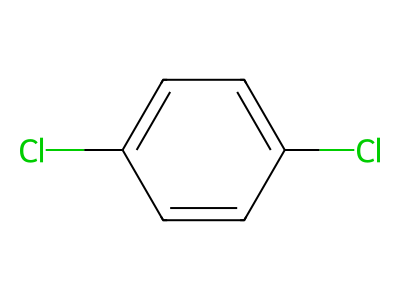

In [8]:
# Example: this molecule has 8 forms on record, but section 4's all-or-nothing check
# would NOT flag it as a "probable duplicate" group, since VERMAG and VERMAG01 are
# genuinely distinct from the rest. Clustering reveals the full picture: only 3 distinct
# polymorphs, one of which (VERMAG07-12) accounts for 6 of the 8 entries.
_ = analyze_given_molecule("C1=CC(=CC=C1Cl)Cl")